# Instance Generation — San Cristóbal de La Laguna

This notebook orchestrates the generation of the HDM problem instance.
It calls the functions defined in `src/generador.py` and visualises
each intermediate result before serialising the final instance to JSON.

**Pipeline:**
1. Download and filter the pedestrian street network (OSMnx)
2. Extract candidate collection points (intersections, degree ≥ 3)
3. Extract buildings and estimate inhabitants (area proxy)
4. Compute sparse Dijkstra distances (cutoff = 350 m)
5. Assemble and save the instance to JSON

In [1]:
import sys
sys.path.insert(0, '../src/python')

import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import json
import math


from instancia import GeographicConfig, ModelParameters, load_instance
from generador import (
    download_graph, extract_candidates, 
    extract_buildings, classify_candidate_context, 
    consolidate_candidates, compute_distances,
    evaluate_coverage, build_instance,
    save_instance
)


## 1. Geographic and model configuration

We define two configuration objects:
- `GeographicConfig` controls the OSMnx download area and graph filtering.
- `ModelParameters` holds all HDM/HVM cost and capacity parameters.

The `radius` parameter (800 m) defines the OSMnx download area.
The `cutoff_dijkstra` parameter (350 m) is stricter — it limits
which building–candidate pairs are considered reachable on foot.

In [ ]:
config = GeographicConfig(
    place="Times Square",
    radius=1000,
    network_type="walk",
    cutoff_dijkstra=350,
    min_node_degree=3,
)

params = ModelParameters(
    opening_cost=4000.0,
    max_bins=8,
    nimby_distance=10.0,
    waste_per_capita=1.32,
    overflow_penalty=500.0,
    bin_cost={0: 350.0, 1: 300.0, 2: 250.0, 3: 500.0},
    bin_capacity={0: 120.0, 1: 120.0, 2: 120.0, 3: 120.0},
    coverage_radius={0: 150.0, 1: 150.0, 2: 250.0, 3: 350.0},
    waste_proportion={0: 0.5012, 1: 0.0791, 2: 0.3885, 3: 0.0312},
    collection_frequency={0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0},
    lognormal_mu=0.0,
    lognormal_sigma=0.25,
    overflow_threshold=0.05,
)

## 2. Street network
Pedestrian network filtered: motorway, trunk and variants removed.

Nodes:  540
Edges:  1650


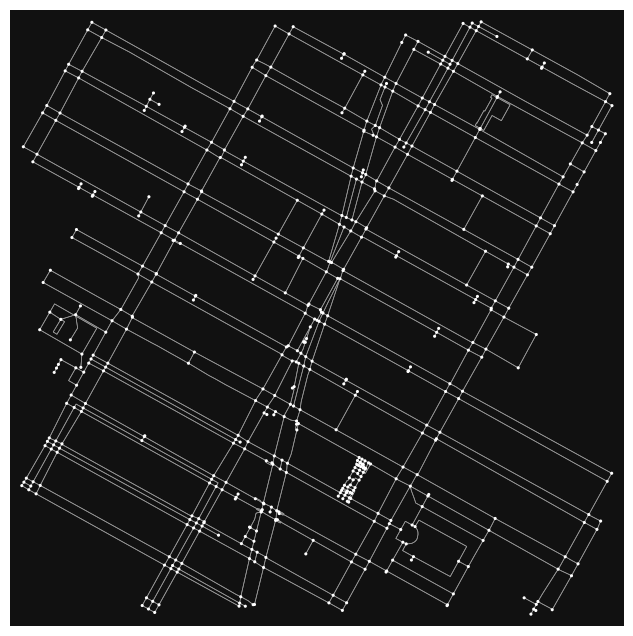

In [9]:
graph = download_graph(config)

print(f"Nodes:  {graph.number_of_nodes()}")
print(f"Edges:  {graph.number_of_edges()}")

fig, ax = ox.plot_graph(
    graph,
    node_size=5,
    edge_linewidth=0.5,
    show=True,
)

## 3. Candidate collection points
Intersections with degree ≥ 3. These are the potential locations for waste collection points.

In [7]:
candidates, idx_to_j, j_to_idx = extract_candidates(graph, config)

print(f"Candidates:      {len(candidates)}")
print(f"idx_to_j[0]:     {idx_to_j[0]}")
print(f"j_to_idx check:  {j_to_idx[idx_to_j[0]] == 0}")
print(f"Example:         {candidates[0]}")

Candidates:      457
idx_to_j[0]:     42433611
j_to_idx check:  True
Example:         CandidateData(osm_id='42433611', latitude=40.7535034, longitude=-73.9887981, context=<CandidateContext.STREET: 'street'>)


## 4. Buildings and demand proxy
Building footprints from OSM. Inhabitants estimated as `area_m2 / ref_surface_m2`.

In [5]:
buildings, i_to_idx, idx_to_i = extract_buildings(config)

print(f"Buildings:        {len(buildings)}")
print(f"Total population: {sum(b.h_i for b in buildings.values()):.1f}")
print(f"Example:          {buildings[0]}")

Buildings:        740
Total population: 9701.2
Example:          BuildingData(osm_id="('relation', 1639376)", latitude=28.488123549675816, longitude=-16.31638697671205, h_i=209.72850176102773)


## 5. Spatial overview
Building footprints and candidate collection points overlaid on the street network.

In [6]:
# Load building footprints for visualisation only
buildings_gdf_viz = ox.features_from_address(
    config.place,
    tags={"building": True},
    dist=config.radius,
)
buildings_gdf_viz = buildings_gdf_viz[
    buildings_gdf_viz.geometry.type.isin(["Polygon", "MultiPolygon"])
].copy()

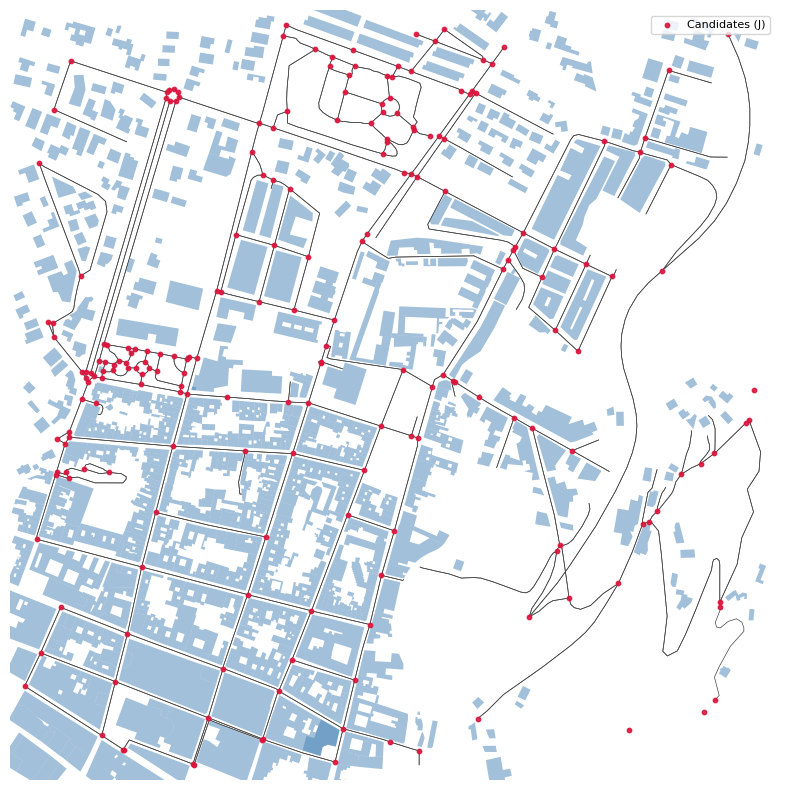

In [7]:
fig, ax = ox.plot_graph(
    graph,
    show=False,
    close=False,
    node_size=0,
    edge_linewidth=0.5,
    edge_color="#444444",
    bgcolor="white",
)

buildings_gdf_viz.plot(
    ax=ax,
    color="steelblue",
    alpha=0.5,
    edgecolor="none",
)

ax.scatter(
    [c.longitude for c in candidates.values()],
    [c.latitude for c in candidates.values()],
    c="crimson", s=10, alpha=0.9, zorder=5, label="Candidates (J)",
)

ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 6. Candidate context classification
Each candidate is labelled by urban context: park, square, roundabout or street.

In [8]:
from collections import Counter

candidates = classify_candidate_context(config, candidates, graph, idx_to_j)

context_counts = Counter(c.context.value for c in candidates.values())
for context, count in context_counts.most_common():
    print(f"{context:20s} {count}")

street               158
park                 44
roundabout           8
square               2


## 7. Candidate consolidation
Park and square candidates excluded. Remaining redundant candidates
consolidated via connected components of a proximity graph.

In [9]:
candidates, idx_to_j, j_to_idx = consolidate_candidates(candidates, graph, idx_to_j)

print(f"Candidates after consolidation: {len(candidates)}")

from collections import Counter
context_counts = Counter(c.context.value for c in candidates.values())
for context, count in context_counts.most_common():
    print(f"  {context:20s} {count}")

Candidates after consolidation: 133
  street               132
  roundabout           1


## 8. Consolidated candidates — visual check
Final candidate set after excluding parks/squares and consolidating redundant nodes.

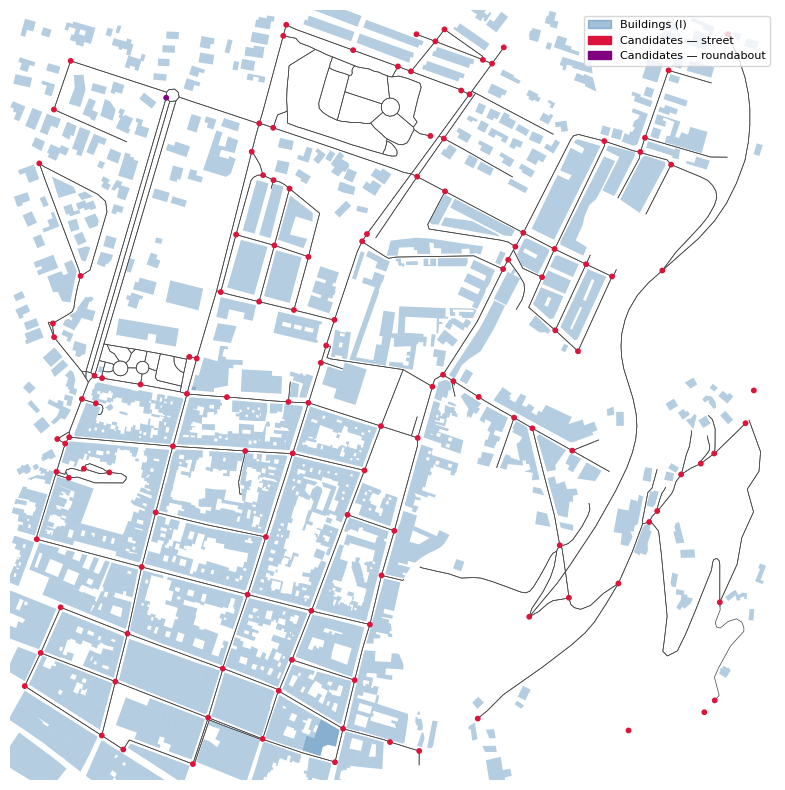

In [10]:
fig, ax = ox.plot_graph(
    graph, show=False, close=False,
    node_size=0, edge_linewidth=0.5,
    edge_color="#444444", bgcolor="white",
)

buildings_gdf_viz.plot(
    ax=ax, color="steelblue", alpha=0.4, edgecolor="none",
)

colors = [
    "crimson" if c.context.value == "street" else "purple"
    for c in candidates.values()
]

ax.scatter(
    [c.longitude for c in candidates.values()],
    [c.latitude for c in candidates.values()],
    c=colors, s=10, zorder=5,
)

legend = [
    mpatches.Patch(color="steelblue", alpha=0.5, label="Buildings (I)"),
    mpatches.Patch(color="crimson",   label="Candidates — street"),
    mpatches.Patch(color="purple",    label="Candidates — roundabout"),
]
ax.legend(handles=legend, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 9. Dijkstra distances
Sparse distance matrix between buildings (I) and candidates (J).
Cutoff = 350m (real network distance).

In [11]:
dij = compute_distances(graph, buildings, candidates, idx_to_j, config.cutoff_dijkstra)

# Summary
total_pairs = sum(len(v) for v in dij.values())
print(f"Candidate-building pairs within cutoff: {total_pairs}")
print(f"Max possible pairs:                     {len(candidates) * len(buildings)}")
print(f"Sparsity:                               {total_pairs / (len(candidates) * len(buildings)) * 100:.1f}%")

# Coverage check
covered = set()
for j_dict in dij.values():
    covered.update(j_dict.keys())
uncovered = set(buildings.keys()) - covered
print(f"\nBuildings with at least one candidate:  {len(covered)}")
print(f"Buildings with no candidate in range:   {len(uncovered)}")

Candidate-building pairs within cutoff: 21873
Max possible pairs:                     98420
Sparsity:                               22.2%

Buildings with at least one candidate:  740
Buildings with no candidate in range:   0


In [12]:
# Check nearest_edges return format
import itertools
sample = dict(itertools.islice(buildings.items(), 1))
i, b = next(iter(sample.items()))
result = ox.distance.nearest_edges(graph, b.longitude, b.latitude, return_dist=True)
print(type(result))
print(result)

<class 'tuple'>
((918748733, 278937961, 0), 0.00042437384187709763)


## 10. Coverage evaluation
Check if all buildings have at least one candidate within each waste type radius.
Empty result means full coverage — no midpoint candidates needed.

In [13]:
uncovered = evaluate_coverage(buildings, dij, params)

if not uncovered:
    print("✓ Full coverage — all buildings reachable for all waste types")
else:
    print(f"✗ {len(uncovered)} buildings without full coverage:")
    for i_idx, missing in uncovered.items():
        b = buildings[i_idx]
        types = [f"k={k}" for k in missing]
        print(f"  Building {i_idx} ({b.osm_id}): missing {types}")

✓ Full coverage — all buildings reachable for all waste types


## 11. Save instance
Serialise the complete instance to JSON.

In [14]:
instance = build_instance(
    config, params, buildings, candidates,
    i_to_idx, idx_to_i, j_to_idx, idx_to_j, dij,
)

save_instance(instance, "../data/processed/instancia_laguna.json")

print(f"Instance saved.")
print(f"  Buildings:    {instance.n_buildings}")
print(f"  Candidates:   {instance.n_candidates}")
print(f"  Connections:  {instance.n_dijkstra_connections}")
print(f"  Population:   {instance.total_population:.1f}")
print(f"  Generated at: {instance.generated_at}")

Instance saved.
  Buildings:    740
  Candidates:   133
  Connections:  21873
  Population:   9701.2
  Generated at: 2026-06-01T12:24:50.637435


## 12. Load and verify instance
Round-trip check: save → load → verify consistency.

In [15]:
instance = load_instance("../data/processed/instancia_laguna.json")

print(f"Study case:   {instance.study_case}")
print(f"Buildings:    {instance.n_buildings}")
print(f"Candidates:   {instance.n_candidates}")
print(f"Connections:  {instance.n_dijkstra_connections}")
print(f"Generated at: {instance.generated_at}")
assert instance.n_buildings == len(instance.I)
assert instance.n_candidates == len(instance.J)
print("✓ Consistency checks passed")

Study case:   Plaza del Cristo, San Cristóbal de La Laguna, España
Buildings:    740
Candidates:   133
Connections:  21873
Generated at: 2026-06-01T12:24:50.637435
✓ Consistency checks passed


## 13. Subinstance for exact solver
Geographic filter to extract a tractable subinstance for Gurobi validation.

In [16]:
# Reference point — centre of the subinstance
LAT_CENTER = 28.4851
LON_CENTER = -16.3165
RADIUS_SUB = 150  # metres

def euclidean_m(lat1, lon1, lat2, lon2):
    lat_m = (lat1 - lat2) * 111_320
    lon_m = (lon1 - lon2) * 111_320 * math.cos(math.radians(lat1))
    return math.sqrt(lat_m**2 + lon_m**2)

# Filter buildings
sub_buildings = {
    idx: b for idx, b in instance.I.items()
    if euclidean_m(b.latitude, b.longitude, LAT_CENTER, LON_CENTER) < RADIUS_SUB
}

# Filter candidates
sub_candidates = {
    idx: c for idx, c in instance.J.items()
    if euclidean_m(c.latitude, c.longitude, LAT_CENTER, LON_CENTER) < RADIUS_SUB
}

print(f"Subinstance buildings:  {len(sub_buildings)}")
print(f"Subinstance candidates: {len(sub_candidates)}")

Subinstance buildings:  0
Subinstance candidates: 0


# PRUEBAS

Parks:       8
Squares:     3
Roundabouts: 8 nodes


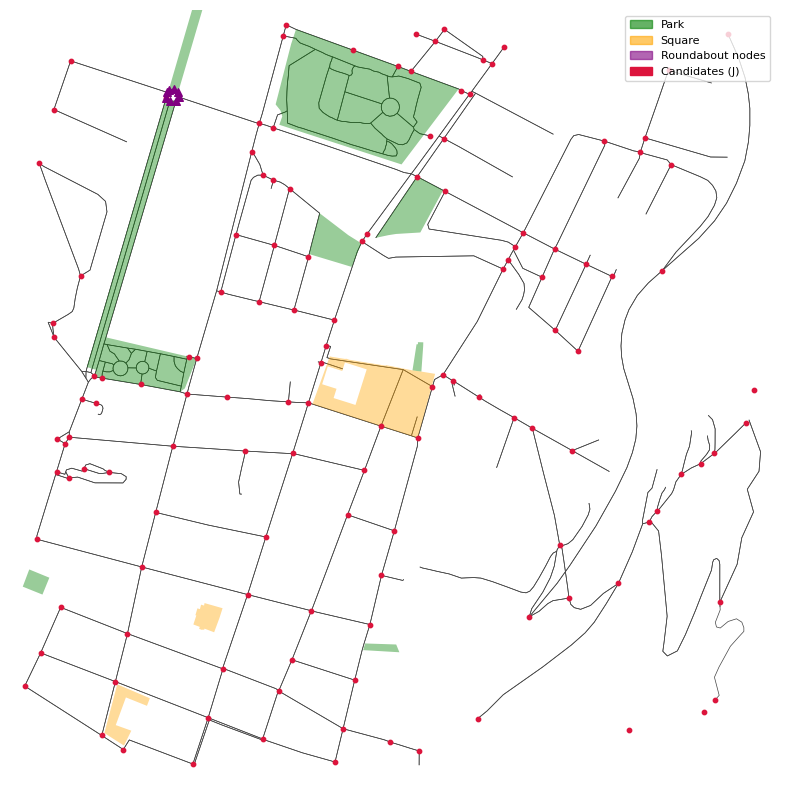

In [17]:
import matplotlib.patches as mpatches

# Download context polygons
parks = ox.features_from_address(config.place, tags={"leisure": "park"}, dist=config.radius)
squares = ox.features_from_address(config.place, tags={"place": "square"}, dist=config.radius)

parks = parks[parks.geometry.type.isin(["Polygon", "MultiPolygon"])]
squares = squares[squares.geometry.type.isin(["Polygon", "MultiPolygon"])]

# Roundabouts from graph edges
roundabout_nodes = set()
for u, v, data in graph.edges(data=True):
    if data.get("junction") == "roundabout":
        roundabout_nodes.add(u)
        roundabout_nodes.add(v)

roundabout_coords = [
    (graph.nodes[n]["x"], graph.nodes[n]["y"])
    for n in roundabout_nodes
    if n in graph.nodes
]

print(f"Parks:       {len(parks)}")
print(f"Squares:     {len(squares)}")
print(f"Roundabouts: {len(roundabout_nodes)} nodes")

# Plot
fig, ax = ox.plot_graph(
    graph, show=False, close=False,
    node_size=0, edge_linewidth=0.5,
    edge_color="#444444", bgcolor="white",
)

if len(parks) > 0:
    parks.plot(ax=ax, color="green", alpha=0.4)
if len(squares) > 0:
    squares.plot(ax=ax, color="orange", alpha=0.4)
if roundabout_coords:
    ax.scatter(
        [c[0] for c in roundabout_coords],
        [c[1] for c in roundabout_coords],
        c="purple", s=30, zorder=6, marker="^", label="Roundabout nodes",
    )

ax.scatter(
    [c.longitude for c in candidates.values()],
    [c.latitude for c in candidates.values()],
    c="crimson", s=10, zorder=5,
)

legend = [
    mpatches.Patch(color="green",  alpha=0.6, label="Park"),
    mpatches.Patch(color="orange", alpha=0.6, label="Square"),
    mpatches.Patch(color="purple", alpha=0.6, label="Roundabout nodes"),
    mpatches.Patch(color="crimson", label="Candidates (J)"),
]
ax.legend(handles=legend, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()